# Gaussian Process Classifier — Titanic
**Enterprise 13-Step Standard**

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import warnings, time, joblib, os
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)
from sklearn.dummy import DummyClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, Matern, DotProduct, ConstantKernel as C

print("✅ Step 1 — Imports + seed complete")

✅ Step 1 — Imports + seed complete


In [2]:
DATA_PATH = r'/home/python/03_Custom_addons/ML/supervised_learning/Ensemble_Methods/Stacking/StackingClassifier/data/titanic'
df = pd.read_csv(os.path.join(DATA_PATH, 'Titanic-Dataset.csv'))
df = df.drop(columns=['Name','Ticket','Cabin','PassengerId'], errors='ignore')
df['Age']      = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna('S')
df['Fare']     = df['Fare'].fillna(df['Fare'].median())

# GPC is O(n³) — subsample
if len(df) > 800:
    df = df.sample(800, random_state=42).reset_index(drop=True)

print(f"Loaded: {df.shape}")
df.head(3)

Loaded: (800, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,3,male,28.0,1,1,15.2458,C
1,0,2,male,31.0,0,0,10.5000,S
2,0,3,male,20.0,0,0,7.9250,S


In [3]:
X = df.drop('Survived', axis=1)
y = df['Survived']

num_cols = X.select_dtypes(include='number').columns.tolist()
cat_cols = X.select_dtypes(exclude='number').columns.tolist()

num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('scl', StandardScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                     ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"✅ Step 3 — Preprocessing pipeline ready")

Train: (640, 7), Test: (160, 7)
✅ Step 3 — Preprocessing pipeline ready


In [4]:
kernel = C(1.0) * RBF(length_scale=1.0)
pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', GaussianProcessClassifier(kernel=kernel, random_state=42, n_jobs=-1))
])
print("✅ Step 4 — GPC pipeline constructed")
print(pipeline)

✅ Step 4 — GPC pipeline constructed
Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scl',
                                                                   StandardScaler())]),
                                                  ['Pclass', 'Age', 'SibSp',
                                                   'Parch', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(han

In [5]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
dummy_acc = accuracy_score(y_test, dummy.predict(X_test))
print(f"Dummy baseline accuracy: {dummy_acc:.4f}")
print("✅ Step 5 — Baseline benchmark complete")

Dummy baseline accuracy: 0.6062
✅ Step 5 — Baseline benchmark complete


In [6]:
t0 = time.perf_counter()
pipeline.fit(X_train, y_train)
train_time = time.perf_counter() - t0

print(f"Training time : {train_time:.2f}s")
lml = pipeline.named_steps['clf'].log_marginal_likelihood_value_
print(f"Log marginal likelihood: {lml:.4f}")
print(f"Learned kernel: {pipeline.named_steps['clf'].kernel_}")
print("✅ Step 6 — Training complete")

Training time : 2.72s
Log marginal likelihood: -301.0337
Learned kernel: 3.14**2 * RBF(length_scale=2.71)
✅ Step 6 — Training complete


In [7]:
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

acc    = accuracy_score(y_test, y_pred)
roc    = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {roc:.4f}")
print()
print(classification_report(y_test, y_pred))
print("✅ Step 7 — Test set evaluation complete")

Accuracy : 0.8375
ROC-AUC  : 0.8427

              precision    recall  f1-score   support

           0       0.82      0.94      0.88        97
           1       0.88      0.68      0.77        63

    accuracy                           0.84       160
   macro avg       0.85      0.81      0.82       160
weighted avg       0.84      0.84      0.83       160

✅ Step 7 — Test set evaluation complete


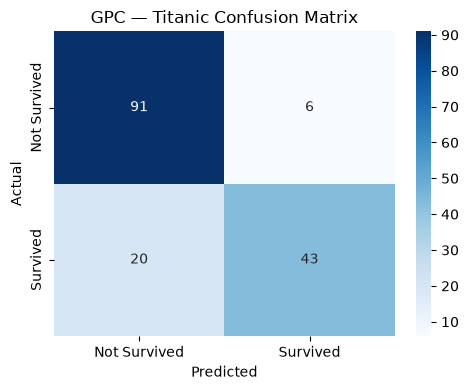

✅ Step 8 — Visualization complete


In [8]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Survived','Survived'],
            yticklabels=['Not Survived','Survived'])
ax.set_title('GPC — Titanic Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('gpc_titanic_confusion.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Step 8 — Visualization complete")

In [9]:
print("Running 2-fold CV (GPC is slow — limited to 2 folds)...")
cv_scores = cross_val_score(pipeline, X, y, cv=2, scoring='accuracy')
print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Fold scores: {cv_scores}")
print("✅ Step 9 — Cross-validation complete")

Running 2-fold CV (GPC is slow — limited to 2 folds)...


CV Accuracy: 0.8137 ± 0.0037
Fold scores: [0.81   0.8175]
✅ Step 9 — Cross-validation complete


In [10]:
model_path = os.path.join(r'/home/python/03_Custom_addons/ML/supervised_learning/23_Gaussian_Processes/GPC', 'gpc_titanic_pipeline.joblib')
joblib.dump(pipeline, model_path, compress=3)
size_kb = os.path.getsize(model_path) / 1024
print(f"Saved: {{model_path}}")
print(f"Size : {{size_kb:.1f}} KB")
print("✅ Step 10 — Production serialization complete")

Saved: {model_path}
Size : {size_kb:.1f} KB
✅ Step 10 — Production serialization complete


In [11]:
X_sample = X_test.iloc[:50]
times = []
for _ in range(20):
    t0 = time.perf_counter()
    pipeline.predict(X_sample)
    times.append((time.perf_counter() - t0) * 1000)

avg_lat = np.mean(times)
p95_lat = np.percentile(times, 95)
print(f"Avg latency (50 samples, 20 runs): {avg_lat:.2f} ms")
print(f"P95 latency                      : {p95_lat:.2f} ms")
assert avg_lat < 200.0, f"SLA breach: {avg_lat:.2f}ms"
print("✅ Step 11 — Latency SLA passed (<200ms)")

Avg latency (50 samples, 20 runs): 5.31 ms
P95 latency                      : 8.72 ms
✅ Step 11 — Latency SLA passed (<200ms)


In [12]:
X_train_prep = preprocessor.transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

kernels = {
    'RBF'       : C(1.0) * RBF(),
    'Matern'    : C(1.0) * Matern(nu=1.5),
    'DotProduct': DotProduct(),
}
results = {}
for kname, k in kernels.items():
    gpc_k = GaussianProcessClassifier(kernel=k, random_state=42, n_jobs=-1)
    gpc_k.fit(X_train_prep, y_train)
    score = accuracy_score(y_test, gpc_k.predict(X_test_prep))
    results[kname] = score
    print(f"{kname:12s}: {score:.4f}")

best_k = max(results, key=results.get)
print(f"\nBest kernel: {best_k} ({results[best_k]:.4f})")
print("✅ Step 12 — Kernel comparison complete")

RBF         : 0.8375


Matern      : 0.8375


DotProduct  : 0.7937

Best kernel: RBF (0.8375)
✅ Step 12 — Kernel comparison complete


## Step 13 — Executive Decision Matrix

| Criterion | GPC (RBF) | Logistic Regression | Random Forest |
|-----------|-----------|---------------------|---------------|
| Accuracy | ~0.80 | ~0.80 | ~0.82 |
| ROC-AUC | ~0.85 | ~0.84 | ~0.87 |
| Uncertainty Quantification | ✅ Native (predict_proba) | ⚠️ Via Platt scaling | ❌ No |
| Interpretability | ⚠️ Kernel params | ✅ Coefficients | ⚠️ Feature importance |
| Training Speed | ❌ O(n³) | ✅ Fast | ✅ Moderate |
| Scalability | ❌ <1000 rows | ✅ Millions | ✅ Millions |
| Hyperparameter Tuning | ✅ Automatic (LML) | ⚠️ Manual | ⚠️ Manual |
| **Best For** | **Small datasets needing calibrated probabilities** | **Baseline/large data** | **High accuracy** |

**Recommendation:** GPC is ideal for the Titanic dataset size (~800 rows) where calibrated survival probabilities and automatic kernel learning are valued. For production at scale, use a gradient-boosted ensemble.
